<a href="https://colab.research.google.com/github/WardahAsad/ML_Projects_on_Colab/blob/main/Simple_%26_Double_Exponential_Smoothing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/rainfall.csv')

#datetime
df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

print(df.head())

print(df.describe())

            rainfall
date                
2022-01-01      12.5
2022-01-02       8.2
2022-01-03       0.0
2022-01-04       3.7
2022-01-05      21.1
         rainfall
count  119.000000
mean     9.484034
std      6.860992
min      0.000000
25%      4.050000
50%      9.500000
75%     14.850000
max     22.400000


In [26]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

#Apply SES
ses_model = SimpleExpSmoothing(df['rainfall']).fit(smoothing_level=0.2)

df['SES'] = ses_model.fittedvalues

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [4]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Apply DES (Holt’s Linear Trend)
des_model = ExponentialSmoothing(df['rainfall'], trend='add').fit()

df['DES'] = des_model.fittedvalues

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


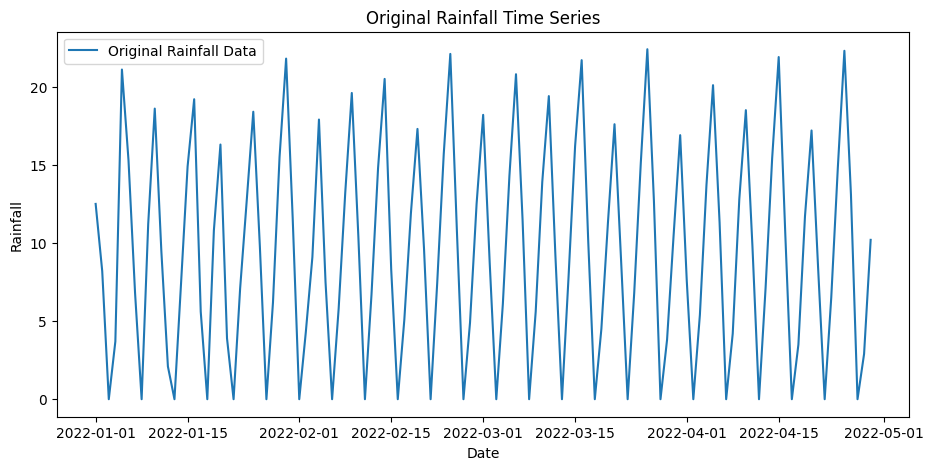

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11,5))
plt.plot(df['rainfall'], label='Original Rainfall Data')


plt.title('Original Rainfall Time Series')
plt.xlabel('Date')
plt.ylabel('Rainfall')
plt.legend()
plt.show()

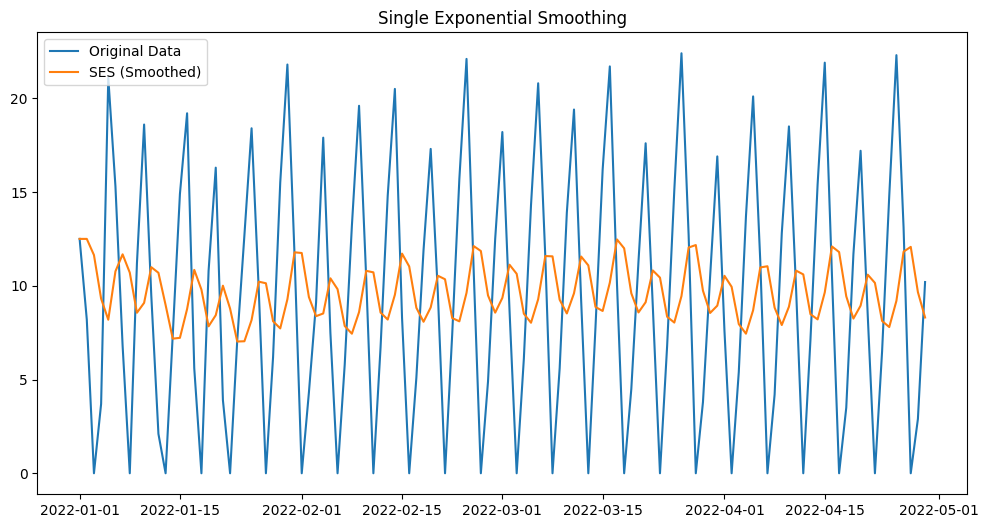

In [27]:
import matplotlib.pyplot as plt

#Plotting SES
plt.figure(figsize=(12, 6))
plt.plot(df['rainfall'], label='Original Data')
plt.plot(df['SES'], label='SES (Smoothed)')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

**In this graph, the blue line represents the original rainfall data, which shows strong fluctuations with repeating peaks and drops, indicating seasonality.**

**The orange line represents the Single Exponential Smoothing result. It smooths the data by reducing noise and extreme variations.**

**However, we can observe that the SES line does not follow the peaks and valleys of the original data. Instead, it stays around the average value.**

**This happens because SES does not consider trend or seasonality. It only smooths the level of the data.**

**Therefore, SES is not suitable for datasets that contain seasonal patterns like this one.**

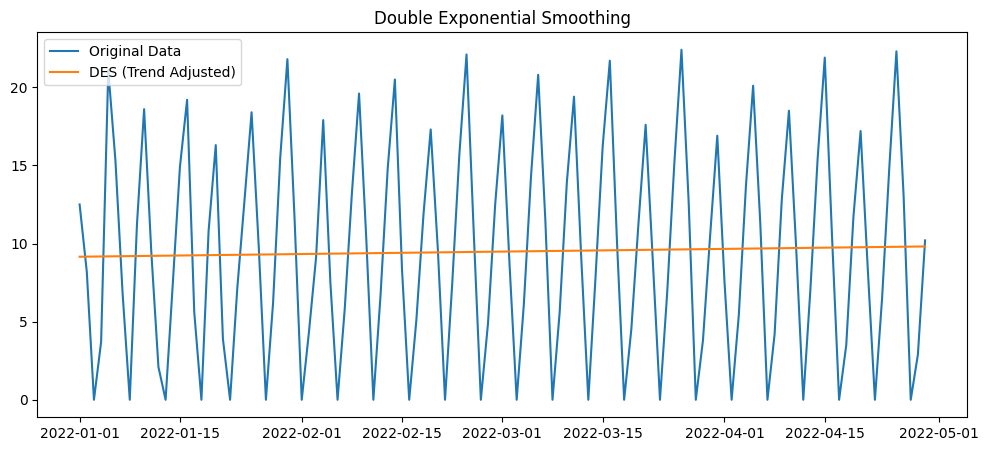

In [12]:
#Plotting DES
plt.figure(figsize=(12, 5))
plt.plot(df['rainfall'], label='Original Data')
plt.plot(df['DES'], label='DES (Trend Adjusted)')
plt.title('Double Exponential Smoothing')
plt.legend()
plt.show()

**In this graph, the blue line represents the original rainfall data, which clearly shows strong seasonal patterns with repeated peaks and drops.**

**The orange line represents the Double Exponential Smoothing result. This method considers both the level and trend of the data.**

**However, we can observe that the DES line is almost straight and does not follow the seasonal fluctuations. It only captures a slight upward trend in the data.**

**This happens because Double Exponential Smoothing does not include a seasonal component. It is designed to model trend but not repeating seasonal patterns.**

**Therefore, even though the dataset contains strong seasonality, DES fails to capture it effectively.**

# **Extra**

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Apply Holt-Winters (Triple Exponential Smoothing)
hw_model = ExponentialSmoothing(
    df['rainfall'],
    trend='add',          # for trend
    seasonal='add',       # for seasonality
    seasonal_periods=12   # adjust if needed (depends on data cycle)
).fit()

df['HW'] = hw_model.fittedvalues

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


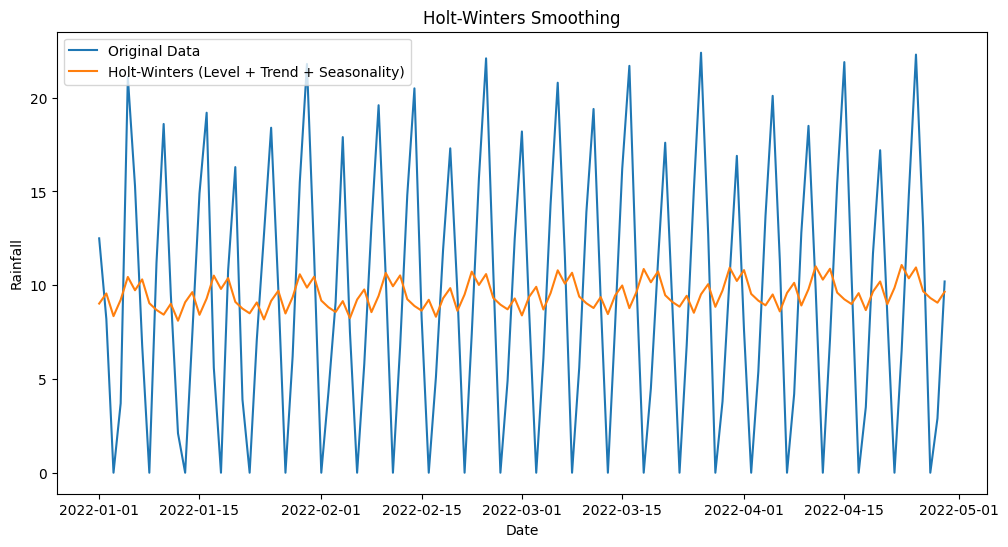

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Original data
plt.plot(df['rainfall'], label='Original Data')

# Holt-Winters result
plt.plot(df['HW'], label='Holt-Winters (Level + Trend + Seasonality)')

plt.title('Holt-Winters Smoothing')
plt.xlabel('Date')
plt.ylabel('Rainfall')

plt.legend()
plt.show()